<a href="https://colab.research.google.com/github/akarthick1/Geospatial_Data_Science/blob/main/Geospatial_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Yield Prediction using Transformer-based Models

This notebook presents a deep learning approach for predicting crop yield using geospatial and environmental data. The methodology leverages Transformer architectures to capture complex temporal and spatial dependencies within the dataset. The objective is to build a robust predictive model that can generalize across varying agricultural conditions.

## Environment Setup

This section initializes the computational environment by importing the necessary libraries for data manipulation, visualization, and model development. Key dependencies include NumPy, Pandas, PyTorch/TensorFlow, and geospatial processing libraries.

In [ ]:
import ee
import geemap
import pandas as pd
import requests
from tqdm import tqdm

## Data Acquisition

The dataset consists of geospatial, climatic, and agricultural variables relevant to crop productivity. Data is loaded from structured sources and prepared for preprocessing. This includes features such as temperature, rainfall, soil properties, and historical yield records.

In [ ]:
# Authenticating Google Earth Engine
ee.Authenticate()

ee.Initialize(project='inspired-berm-488918-k2')

In [ ]:
# Texas, Missouri , Iowa , Nebraska , Kansas
states_fips = ['48', '29', '19', '31', '20']

counties = ee.FeatureCollection("TIGER/2018/Counties") \
    .filter(ee.Filter.inList('STATEFP', states_fips))

In [ ]:

def get_soil_moisture(start_date, end_date):
    return ee.ImageCollection("NASA/SMAP/SPL4SMGP/007") \
        .filterDate(start_date, end_date) \
        .select('sm_surface') \
        .map(lambda img: img.rename('soil_moisture'))


def get_weather(start_date, end_date):
    return ee.ImageCollection("IDAHO_EPSCOR/GRIDMET") \
        .filterDate(start_date, end_date) \
        .select(['tmmx', 'tmmn', 'pr'])

In [ ]:
def create_seasonal_series(year):
    start_date_str = f"{year}-04-01"
    end_date_str   = f"{year}-10-31"
    start_base     = ee.Date(start_date_str)

    sm      = get_soil_moisture(start_date_str, end_date_str)
    weather = get_weather(start_date_str, end_date_str)

    def composite(offset):
        start = start_base.advance(offset, 'day')
        end   = start.advance(16, 'day')


        veg_start = start.advance(-8, 'day')
        veg_end   = end.advance(8, 'day')

        veg = ee.ImageCollection("MODIS/061/MOD13Q1") \
            .filterDate(veg_start, veg_end) \
            .select(['NDVI', 'EVI']) \
            .map(lambda img: img.multiply(0.0001))

        veg_mean = veg.mean()
        sm_mean  = sm.filterDate(start, end).mean()

        w_filtered = weather.filterDate(start, end)
        w_mean     = w_filtered.select(['tmmx', 'tmmn']).mean()
        w_sum      = w_filtered.select(['pr']).sum()

        combined = ee.Image([veg_mean, sm_mean, w_mean, w_sum])

        return combined.set({
            'system:time_start': start.millis(),
            'year':              year,
            'band_count':        combined.bandNames().size(),
            'date_string':       start.format('YYYY-MM-dd')
        })

    offsets = ee.List.sequence(0, 180, 16)
    return ee.ImageCollection(offsets.map(composite))

In [ ]:
def apply_crop_mask(collection, year):
    cdl = ee.ImageCollection("USDA/NASS/CDL").filterDate(f'{year}-01-01', f'{year}-12-31').first()
    corn_mask = cdl.select('cropland').eq(1)

    return collection.map(lambda img: img.updateMask(corn_mask))

In [ ]:
def extract_features(image):
    date_val = image.get('date_string')
    year_val = image.get('year')

    stats = image.reduceRegions(
        collection=counties,
        reducer=ee.Reducer.mean(),
        scale=500,
        tileScale=4
    )

    return stats.map(lambda f: ee.Feature(None, {
        'date':          date_val,
        'year':          year_val,
        'county_fips':   f.get('GEOID'),
        'county_name':   f.get('NAME'),
        'NDVI':          f.get('NDVI'),
        'EVI':           f.get('EVI'),
        'pr':            f.get('pr'),
        'soil_moisture': f.get('soil_moisture'),
        'tmmn':          f.get('tmmn'),
        'tmmx':          f.get('tmmx'),
    }))

In [ ]:
all_features_list = []

for year in years:
    print(f"Processing {year}...")
    seasonal = create_seasonal_series(year)
    valid_seasonal = seasonal.filter(ee.Filter.gt('band_count', 0))
    masked = apply_crop_mask(valid_seasonal, year)
    features = masked.map(extract_features).flatten()
    all_features_list.append(features)


merged = ee.FeatureCollection(all_features_list).flatten()


export_columns = [
    'date', 'year', 'county_fips', 'county_name',
    'NDVI', 'EVI', 'pr', 'soil_moisture', 'tmmn', 'tmmx'
]

task = ee.batch.Export.table.toDrive(
    collection=merged,
    description='Crop_Features_2015_2024_Clean',
    folder='Geospatial',
    fileNamePrefix='satellite',
    fileFormat='CSV',
    selectors=export_columns
)

task.start()
print("Export started!")

Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
Export started!


/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


In [ ]:
print(task.status())

{'state': 'COMPLETED', 'description': 'Crop_Features_2015_2024_Clean', 'priority': 100, 'creation_timestamp_ms': 1777617805040, 'update_timestamp_ms': 1777618247732, 'start_timestamp_ms': 1777617806582, 'task_type': 'EXPORT_FEATURES', 'destination_uris': ['https://drive.google.com/#folders/1pZ2P1VLcgMBLsq5fKwGTOKUzoMEk8NWX'], 'attempt': 1, 'batch_eecu_usage_seconds': 112677.84375, 'id': 'PRQZUWAF3IPSLYU3FK5WILIE', 'name': 'projects/inspired-berm-488918-k2/operations/PRQZUWAF3IPSLYU3FK5WILIE'}


/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
xpath = "/content/drive/MyDrive/Geospatial/satellite.csv"
ypath = "/content/drive/MyDrive/Geospatial/YDModified.csv"

x_df = pd.read_csv(xpath)
y_df = pd.read_csv(ypath)

In [ ]:
x_df

,date,year,county_fips,county_name,NDVI,EVI,pr,soil_moisture,tmmn,tmmx
0,2015-04-01,2015,29510,St. Louis,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-04-01,2015,19149,Plymouth,0.275577,0.174896,38.735636,0.294846,275.605629,290.062662
2,2015-04-01,2015,19193,Woodbury,0.272688,0.165134,58.401207,0.316546,276.570447,290.103035
3,2015-04-01,2015,19027,Carroll,0.271906,0.165268,62.435145,0.289558,276.443330,289.767585
4,2015-04-01,2015,19061,Dubuque,0.333978,0.218878,39.425673,0.294381,275.645827,289.628310
...,...,...,...,...,...,...,...,...,...,...
79915,2024-09-24,2024,48003,Andrews,NaN,NaN,NaN,NaN,NaN,NaN
79916,2024-09-24,2024,48055,Caldwell,0.317851,0.190575,0.195055,0.186006,290.360251,307.210972
79917,2024-09-24,2024,48209,Hays,0.330061,0.216480,0.178565,0.191803,290.356452,307.041251
79918,2024-09-24,2024,20071,Greeley,0.281148,0.185484,0.000000,0.067888,280.029380,302.123422


In [ ]:
y_df

,Year,State,State ANSI,County,Value
0,2024,IOWA,19,OTHER COUNTIES,205.7
1,2024,IOWA,19,BOONE,217.6
2,2024,IOWA,19,HAMILTON,212.3
3,2024,IOWA,19,MARSHALL,222.2
4,2024,IOWA,19,POLK,218.0
...,...,...,...,...,...
3693,2015,TEXAS,48,JACKSON,83.1
3694,2015,TEXAS,48,MATAGORDA,82.9
3695,2015,TEXAS,48,OTHER (COMBINED) COUNTIES,89.4
3696,2015,TEXAS,48,VICTORIA,73.5


In [ ]:
print("Satellite shape:", x_df.shape)
print("Yield shape:    ", y_df.shape)
print("\nSatellite columns:", x_df.columns.tolist())
print("Yield columns:    ", y_df.columns.tolist())

Satellite shape: (79920, 10)
Yield shape:     (3698, 5)

Satellite columns: ['date', 'year', 'county_fips', 'county_name', 'NDVI', 'EVI', 'pr', 'soil_moisture', 'tmmn', 'tmmx']
Yield columns:     ['Year', 'State', 'State ANSI', 'County', 'Value']


**Data Pre-Processing Steps**

In [ ]:
#Cleaning the Satellite Data
import re

feature_cols = ['NDVI', 'EVI', 'pr', 'soil_moisture', 'tmmn', 'tmmx']

def clean_county(name):
    name = str(name).upper().strip()
    name = re.sub(r'[.\'-]', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    name = re.sub(r'\bDE\s+([A-Z])', r'DE\1', name)
    return name

x_df['county_name_clean'] = x_df['county_name'].apply(clean_county)

x_df['date'] = pd.to_datetime(x_df['date'], format='%Y-%m-%d')
x_df['year'] = x_df['year'].astype(int)
x_df['county_fips'] = x_df['county_fips'].astype(str).str.zfill(5)
x_df['state_fips']  = x_df['county_fips'].str[:2]


fips_to_state = {'19': 'IOWA', '20': 'KANSAS', '29': 'MISSOURI',
                 '31': 'NEBRASKA', '48': 'TEXAS'}
x_df['state'] = x_df['state_fips'].map(fips_to_state)

x_df = x_df.sort_values(['county_fips', 'year', 'date']).reset_index(drop=True)

for col in feature_cols:
    x_df[col] = x_df.groupby('county_fips')[col] \
                    .transform(lambda s: s.interpolate(method='linear',
                                                        limit_direction='both'))

print("Satellite cleaned:", x_df.shape)
print("Date dtype:", x_df['date'].dtype)
print("Sample dates:", x_df['date'].head(3).tolist())

Satellite cleaned: (79920, 13)
Date dtype: datetime64[ns]
Sample dates: [Timestamp('2015-04-01 00:00:00'), Timestamp('2015-04-17 00:00:00'), Timestamp('2015-05-03 00:00:00')]


In [ ]:
import warnings

all_dates_per_year = (
    x_df.groupby('year')['date']
        .apply(lambda d: sorted(d.dropna().unique()))
        .to_dict()
)

# Verify all years have 12 dates
for yr, dates in all_dates_per_year.items():
    print(f"{yr}: {len(dates)} dates")

def fill_missing_rows(group):
    year   = int(group['year'].iloc[0])
    county = str(group['county_fips'].iloc[0])

    all_dates = all_dates_per_year.get(year, [])
    if not all_dates or len(group) == len(all_dates):
        return group

    group = group.copy().set_index('date')
    group = group.reindex(pd.DatetimeIndex(all_dates))

    for col in ['year', 'county_fips', 'county_name', 'county_name_clean',
                'state_fips', 'state']:
        if col in group.columns:
            group[col] = group[col].ffill().bfill()

    for col in feature_cols:
        group[col] = group[col].interpolate(method='linear',
                                             limit_direction='both')

    return group.reset_index().rename(columns={'index': 'date'})

2015: 12 dates
2016: 12 dates
2017: 12 dates
2018: 12 dates
2019: 12 dates
2020: 12 dates
2021: 12 dates
2022: 12 dates
2023: 12 dates
2024: 12 dates


In [ ]:
# Dealing with Missing Values
x_df = (x_df.groupby(['county_fips', 'year'], group_keys=False)
             .apply(fill_missing_rows)
             .reset_index(drop=True))

x_df = x_df.sort_values(['county_fips', 'year', 'date']).reset_index(drop=True)


for col in feature_cols:
    x_df[col] = (x_df.groupby('county_fips')[col]
                     .transform(lambda s: s.interpolate(method='linear',
                                                         limit_direction='both')))

print("Null values remaining after fix:")
print(x_df[feature_cols].isnull().sum())

null_mask = x_df.groupby(['county_fips', 'year'])[feature_cols] \
                .transform(lambda s: s.isnull().all())

fully_null_groups = null_mask.any(axis=1)
print(f"\nRows in fully-null county-year groups: {fully_null_groups.sum()}")

x_df = x_df[~fully_null_groups].reset_index(drop=True)

print(f"\nShape after dropping ungfillable groups: {x_df.shape}")
print(f"Null values after drop:\n{x_df[feature_cols].isnull().sum()}")
print(f"Timestep counts:\n{x_df.groupby(['county_fips','year']).size().value_counts()}")

/tmp/ipykernel_4056/1156710191.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fill_missing_rows)


Null values remaining after fix:
NDVI             7920
EVI              7920
pr               7920
soil_moisture    7920
tmmn             7920
tmmx             7920
dtype: int64

Rows in fully-null county-year groups: 7920

Shape after dropping ungfillable groups: (72000, 13)
Null values after drop:
NDVI             0
EVI              0
pr               0
soil_moisture    0
tmmn             0
tmmx             0
dtype: int64
Timestep counts:
12    6000
Name: count, dtype: int64


In [ ]:
print(f"Unique counties : {x_df['county_fips'].nunique()}")
print(f"Unique years    : {x_df['year'].nunique()}  → {sorted(x_df['year'].unique())}")
print(f"Unique states   : {x_df['state'].unique()}")

Unique counties : 600
Unique years    : 10  → [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Unique states   : ['IOWA' 'KANSAS' 'MISSOURI' 'NEBRASKA' 'TEXAS']


In [ ]:
y_df.columns = ['year', 'state', 'state_ansi', 'county_name', 'yield']

y_df['county_name_clean'] = y_df['county_name'].apply(clean_county)

y_df['year']             = y_df['year'].astype(int)
y_df['state_ansi']       = y_df['state_ansi'].astype(str).str.zfill(2)
y_df['county_name_clean']= y_df['county_name'].apply(clean_county)

y_df['yield']            = pd.to_numeric(y_df['yield'], errors='coerce') # Droping Rows Like "Other County"


y_df = y_df[~y_df['county_name_clean'].str.contains('OTHER', na=False)]
y_df = y_df.dropna(subset=['yield']).reset_index(drop=True)

print("Yield data shape after cleaning:", y_df.shape)
print("States in yield data:", y_df['state'].unique())
print("Years  in yield data:", sorted(y_df['year'].unique()))

Yield data shape after cleaning: (3500, 6)
States in yield data: ['IOWA' 'KANSAS' 'MISSOURI' 'NEBRASKA' 'TEXAS']
Years  in yield data: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
y_merge = y_df[['year', 'state_ansi', 'county_name_clean', 'yield']].copy()
y_merge.rename(columns={'state_ansi': 'state_fips'}, inplace=True)

merged = x_df.merge(y_merge,
                    on=['year', 'state_fips', 'county_name_clean'],
                    how='inner')

print(f"Merged shape          : {merged.shape}")
print(f"Unique county-year pairs: {merged.groupby(['county_fips','year']).ngroups}")
print(f"Null values in merged :\n{merged[feature_cols].isnull().sum()}")

sat_keys   = set(zip(x_df['state_fips'],  x_df['county_name_clean']))
yield_keys = set(zip(y_df['state_ansi'],  y_df['county_name_clean']))

unmatched_sat   = sat_keys - yield_keys
unmatched_yield = yield_keys - sat_keys

print(f"\nSatellite counties not in yield : {len(unmatched_sat)}")
print(f"Yield counties not in satellite : {len(unmatched_yield)}")

if unmatched_sat:
    print("\nSample unmatched satellite counties:")
    print(list(unmatched_sat)[:10])

if unmatched_yield:
    print("\nSample unmatched yield counties:")
    print(list(unmatched_yield)[:10])

Merged shape          : (42000, 14)
Unique county-year pairs: 3500
Null values in merged :
NDVI             0
EVI              0
pr               0
soil_moisture    0
tmmn             0
tmmx             0
dtype: int64

Satellite counties not in yield : 115
Yield counties not in satellite : 0

Sample unmatched satellite counties:
[('48', 'GRIMES'), ('48', 'BASTROP'), ('48', 'GAINES'), ('48', 'DAWSON'), ('48', 'VAN ZANDT'), ('48', 'PECOS'), ('48', 'YOUNG'), ('48', 'BROOKS'), ('48', 'TITUS'), ('48', 'DIMMIT')]


In [ ]:
!pip install geopandas --quiet
!pip install mapclassify --quiet

In [ ]:


import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
import warnings
warnings.filterwarnings('ignore')

corn_density = (merged
    .groupby(['county_fips', 'county_name', 'state'])
    .agg(
        valid_obs    = ('NDVI',  'count'),
        mean_yield   = ('yield', 'mean'),
        years_active = ('year',  'nunique'),
        mean_ndvi    = ('NDVI',  'mean'),
    )
    .reset_index()
)

def normalize_within_state(group):
    mn = group['valid_obs'].min()
    mx = group['valid_obs'].max()
    group['corn_coverage'] = (group['valid_obs'] - mn) / (mx - mn + 1e-9)
    return group

corn_density = (corn_density
    .groupby('state', group_keys=False)
    .apply(normalize_within_state)
    .reset_index(drop=True)
)

corn_density['county_fips'] = corn_density['county_fips'].astype(str).str.zfill(5)
print(f"Counties with corn data: {len(corn_density)}")
print(corn_density.head())

Counties with corn data: 485
  county_fips county_name state  valid_obs  mean_yield  years_active  \
0       19001       Adair  IOWA         96    176.5125             8   
1       19003       Adams  IOWA         60    176.3600             5   
2       19005   Allamakee  IOWA        120    196.7500            10   
3       19007   Appanoose  IOWA         96    163.9375             8   
4       19009     Audubon  IOWA        120    200.9600            10   

   mean_ndvi  corn_coverage  
0   0.623623            0.6  
1   0.635243            0.0  
2   0.655163            1.0  
3   0.651243            0.6  
4   0.604946            1.0  


Geo-merged counties: 485


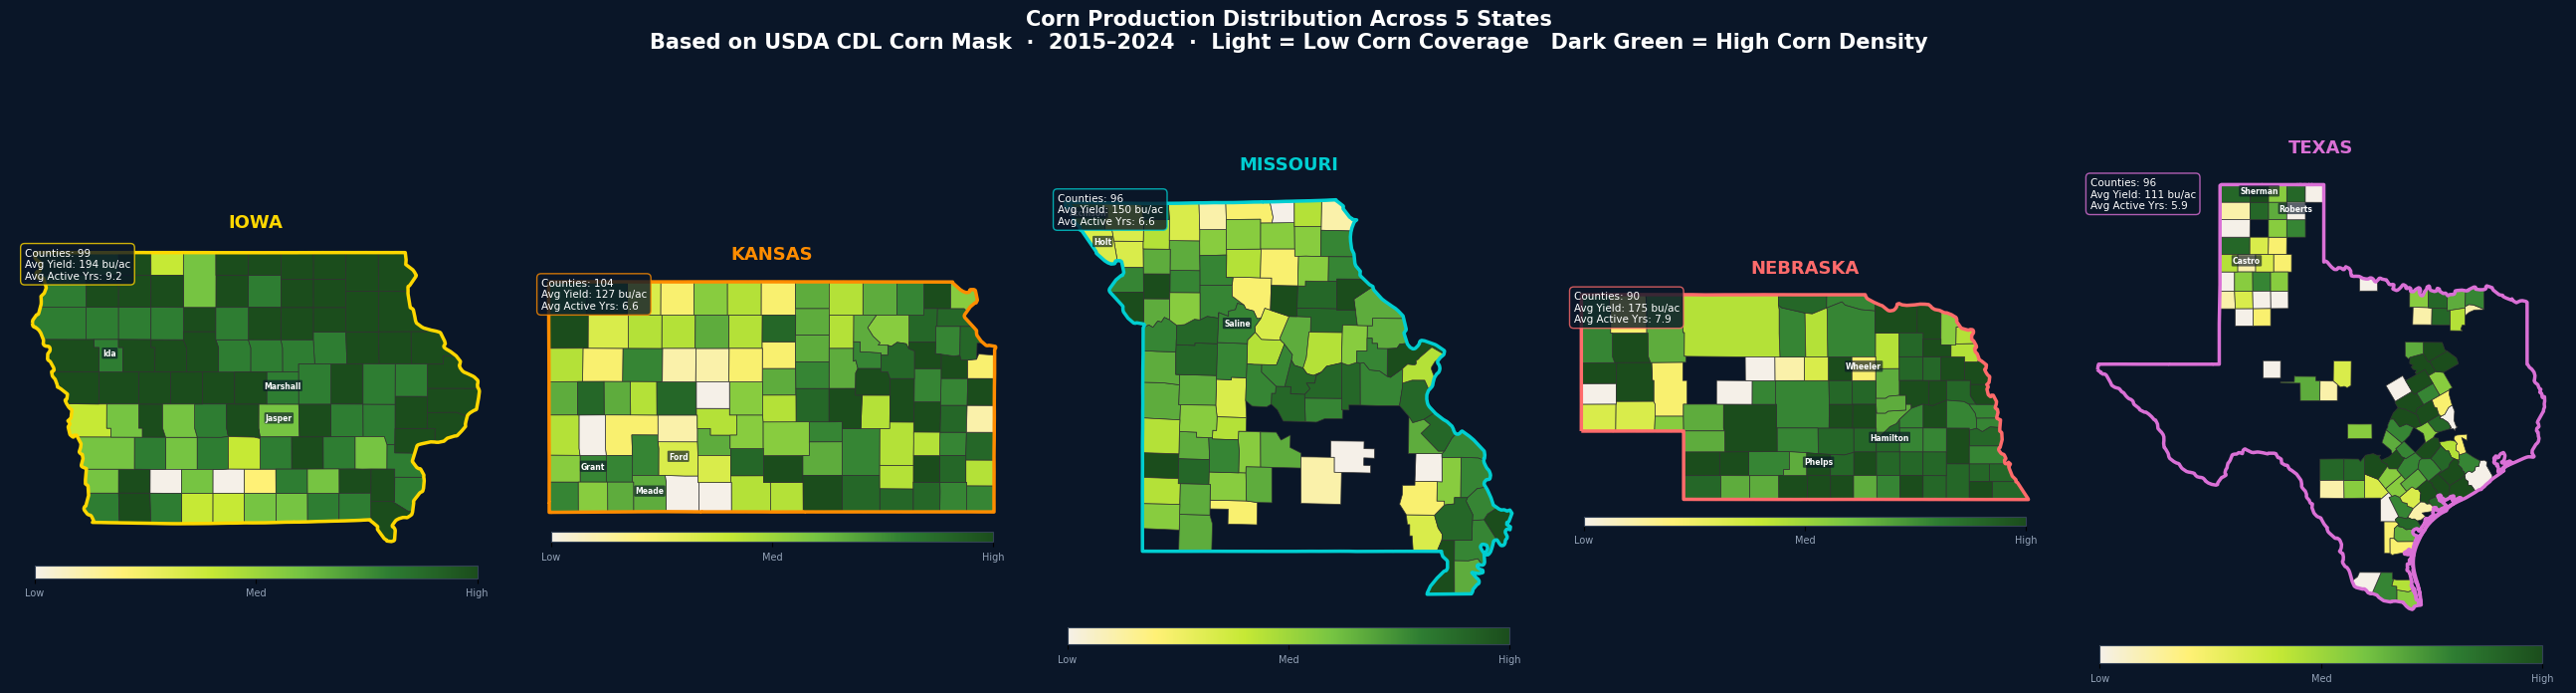

In [ ]:

url = "https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/US-counties.geojson"
counties_geo = gpd.read_file(url)
counties_geo['id'] = counties_geo['id'].astype(str).str.zfill(5)

geo_corn = counties_geo.merge(
    corn_density,
    left_on  = 'id',
    right_on = 'county_fips',
    how      = 'right'
)
geo_corn = gpd.GeoDataFrame(geo_corn, geometry='geometry')
geo_corn = geo_corn[geo_corn['geometry'].notna()]

# State outlines
state_fips_map = {
    'IOWA': '19', 'KANSAS': '20',
    'MISSOURI': '29', 'NEBRASKA': '31', 'TEXAS': '48'
}
state_geo = counties_geo.copy()
state_geo['state_fips'] = state_geo['id'].str[:2]
state_outlines = (state_geo[state_geo['state_fips']
                  .isin(state_fips_map.values())]
                  .dissolve(by='state_fips')
                  .reset_index())

print(f"Geo-merged counties: {len(geo_corn)}")

corn_cmap = LinearSegmentedColormap.from_list(
    'CornDensity',
    ['#F5F0E8', '#FFF176', '#C6E935', '#76C442', '#2E7D32', '#1B4D1C'],
    N=512
)

states_order  = ['IOWA', 'KANSAS', 'MISSOURI', 'NEBRASKA', 'TEXAS']
border_colors = {
    'IOWA':     '#FFD700',
    'KANSAS':   '#FF8C00',
    'MISSOURI': '#00CED1',
    'NEBRASKA': '#FF6B6B',
    'TEXAS':    '#DA70D6'
}

fig, axes = plt.subplots(1, 5, figsize=(26, 7), facecolor='#0A1628')
fig.patch.set_facecolor('#0A1628')

fig.suptitle(
    'Corn Production Distribution Across 5 States\n'
    'Based on USDA CDL Corn Mask  ·  2015–2024  ·  '
    'Light = Low Corn Coverage   Dark Green = High Corn Density',
    fontsize=15, fontweight='bold', color='white', y=1.04
)

for col_idx, state in enumerate(states_order):
    ax = axes[col_idx]
    ax.set_facecolor('#0D1F35')

    state_data = geo_corn[geo_corn['state'] == state].copy()

    if state_data.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', color='white')
        ax.set_axis_off()
        continue


    state_data.plot(
        column       = 'corn_coverage',
        ax           = ax,
        cmap         = corn_cmap,
        vmin         = 0,
        vmax         = 1,
        edgecolor    = '#333333',
        linewidth    = 0.5,
        missing_kwds = dict(color='#1A2A3A',
                            edgecolor='#333333',
                            linewidth=0.3)
    )


    sfips   = state_fips_map[state]
    outline = state_outlines[state_outlines['state_fips'] == sfips]
    if not outline.empty:
        outline.boundary.plot(
            ax        = ax,
            color     = border_colors[state],
            linewidth = 2.5,
            zorder    = 5
        )


    top3 = state_data.nlargest(3, 'mean_yield')
    for _, row in top3.iterrows():
        if row['geometry'] is not None:
            cx = row['geometry'].centroid.x
            cy = row['geometry'].centroid.y
            ax.annotate(
                row['county_name'],
                xy         = (cx, cy),
                fontsize   = 5.5,
                color      = 'white',
                ha         = 'center',
                fontweight = 'bold',
                bbox       = dict(boxstyle='round,pad=0.15',
                                  facecolor='#0A1628',
                                  alpha=0.65,
                                  edgecolor='none'),
                zorder=8
            )

    n_counties  = len(state_data)
    avg_yield   = state_data['mean_yield'].mean()
    total_years = state_data['years_active'].mean()

    stats_txt = (f'Counties: {n_counties}\n'
                 f'Avg Yield: {avg_yield:.0f} bu/ac\n'
                 f'Avg Active Yrs: {total_years:.1f}')
    ax.text(
        0.03, 0.97, stats_txt,
        transform  = ax.transAxes,
        fontsize   = 7.5,
        color      = 'white',
        ha='left', va='top',
        bbox=dict(
            boxstyle  = 'round,pad=0.4',
            facecolor = '#0A1628',
            alpha     = 0.80,
            edgecolor = border_colors[state],
            linewidth = 1.0
        ),
        zorder=10
    )


    cax = ax.inset_axes([0.05, -0.07, 0.9, 0.04])
    cb  = ColorbarBase(
        cax,
        cmap        = corn_cmap,
        norm        = mcolors.Normalize(vmin=0, vmax=1),
        orientation = 'horizontal'
    )
    cb.set_ticks([0, 0.5, 1.0])
    cb.set_ticklabels(['Low', 'Med', 'High'], fontsize=7, color='#94A3B8')
    cb.outline.set_edgecolor('#334155')

    ax.set_title(
        state,
        fontsize   = 13,
        fontweight = 'bold',
        color      = border_colors[state],
        pad        = 8
    )
    ax.set_axis_off()

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(wspace=0.05)
plt.savefig('corn_distribution_maps.png', dpi=600,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()

**Building sequene for Tranformer Input**

In [ ]:

sequences, labels, meta = [], [], []

for (county, year), group in merged.groupby(['county_fips', 'year']):
    group = group.sort_values('date')

    if len(group) != EXPECTED_T:
        continue

    seq = group[feature_cols].values
    sequences.append(seq)
    labels.append(group['yield'].iloc[0])
    meta.append({
        'county_fips': county,
        'county_name': group['county_name'].iloc[0],
        'state':       group['state'].iloc[0],
        'year':        year
    })

X       = np.array(sequences)
y       = np.array(labels)
meta_df = pd.DataFrame(meta)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

X shape : (3500, 12, 6)
y shape : (3500,)


**Data Splitting**

In [ ]:
train_mask = meta_df['year'].isin(range(2015, 2022)).values
test_mask  = meta_df['year'].isin(range(2022, 2025)).values

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train → X: {X_train.shape}, y: {y_train.shape}")
print(f"Test  → X: {X_test.shape},  y: {y_test.shape}")
print(f"Train years: {sorted(meta_df[train_mask]['year'].unique())}")
print(f"Test  years: {sorted(meta_df[test_mask]['year'].unique())}")

Train → X: (2493, 12, 6), y: (2493,)
Test  → X: (1007, 12, 6),  y: (1007,)
Train years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Test  years: [np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

N_tr, T, F = X_train.shape

feat_scaler  = StandardScaler()
X_train_sc   = feat_scaler.fit_transform(
                    X_train.reshape(-1, F)).reshape(N_tr, T, F)
X_test_sc    = feat_scaler.transform(
                    X_test.reshape(-1, F)).reshape(len(X_test), T, F)

yield_scaler = StandardScaler()
y_train_sc   = yield_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_sc    = yield_scaler.transform(y_test.reshape(-1,1)).ravel()

print(f"X_train scaled: {X_train_sc.shape}")
print(f"X_test  scaled: {X_test_sc.shape}")
print(f"y_train mean: {y_train_sc.mean():.4f}, std: {y_train_sc.std():.4f}")
print(f"y_test  mean: {y_test_sc.mean():.4f},  std: {y_test_sc.std():.4f}")

X_train scaled: (2493, 12, 6)
X_test  scaled: (1007, 12, 6)
y_train mean: 0.0000, std: 1.0000
y_test  mean: -0.0734,  std: 1.1799


In [ ]:

import os
save_dir = "/content/drive/MyDrive/Geospatial/processed/"
os.makedirs(save_dir, exist_ok=True)

# Arrays
np.save(save_dir + 'X_train.npy',     X_train_sc)
np.save(save_dir + 'X_test.npy',      X_test_sc)
np.save(save_dir + 'y_train.npy',     y_train_sc)
np.save(save_dir + 'y_test.npy',      y_test_sc)
np.save(save_dir + 'X_train_raw.npy', X_train)
np.save(save_dir + 'X_test_raw.npy',  X_test)

# Scalers
joblib.dump(feat_scaler,  save_dir + 'feature_scaler.pkl')
joblib.dump(yield_scaler, save_dir + 'yield_scaler.pkl')

# Meta
meta_df.to_csv(save_dir + 'meta.csv', index=False)

print(f"\n{'='*40}")
print(f"FINAL SUMMARY")
print(f"{'='*40}")
print(f"Total samples       : {len(X)}")
print(f"Train samples       : {len(X_train)}  (2015–2021)")
print(f"Test  samples       : {len(X_test)}   (2022–2024)")
print(f"Sequence length (T) : {T}")
print(f"Features (F)        : {F}  {feature_cols}")
print(f"Tensor shape        : (N, T, F) = (N, {T}, {F})")
print(f"{'='*40}")


FINAL SUMMARY
Total samples       : 3500
Train samples       : 2493  (2015–2021)
Test  samples       : 1007   (2022–2024)
Sequence length (T) : 12
Features (F)        : 6  ['NDVI', 'EVI', 'pr', 'soil_moisture', 'tmmn', 'tmmx']
Tensor shape        : (N, T, F) = (N, 12, 6)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class CropSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, T, F)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CropSequenceDataset(X_train_sc, y_train_sc)
test_dataset  = CropSequenceDataset(X_test_sc,  y_test_sc)

train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

# Verify one batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape : {X_batch.shape}")
print(f"Batch y shape : {y_batch.shape}")

Batch X shape : torch.Size([64, 12, 6])
Batch y shape : torch.Size([64])


In [ ]:
class CropSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx): return self.X[idx], self.y[idx]

In [ ]:
import torch
import torch.nn as nn
import math
import numpy as np
from torch.utils.data import Dataset, DataLoader
import joblib

class CropSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=12, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe     = torch.zeros(max_len, d_model)
        pos    = torch.arange(max_len).unsqueeze(1)
        div    = torch.exp(torch.arange(0, d_model, 2) *
                           -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])

Building the Transformer Architecture

In [ ]:
class CropYieldTransformer(nn.Module):
    def __init__(self,
                 input_dim   = 6,
                 d_model     = 64,
                 nhead       = 4,
                 num_layers  = 3,
                 dim_ff      = 128,
                 dropout     = 0.1,
                 max_len     = 12):
        super().__init__()


        self.input_proj = nn.Linear(input_dim, d_model)


        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)


        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_ff,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers     = num_layers,
            norm           = nn.LayerNorm(d_model)
        )


        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.head(x).squeeze(-1)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device, y_scaler=None):
    model.eval()
    total_loss, preds_all, targets_all = 0.0, [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model(X_batch)
        total_loss += criterion(pred, y_batch).item() * len(y_batch)
        preds_all.append(pred.cpu())
        targets_all.append(y_batch.cpu())

    preds   = torch.cat(preds_all).numpy()
    targets = torch.cat(targets_all).numpy()

    # Inverse transform if scaler provided → metrics in original units (bu/acre)
    if y_scaler:
        preds   = y_scaler.inverse_transform(preds.reshape(-1,1)).ravel()
        targets = y_scaler.inverse_transform(targets.reshape(-1,1)).ravel()

    rmse = np.sqrt(np.mean((preds - targets)**2))
    mae  = np.mean(np.abs(preds - targets))
    ss_res = np.sum((targets - preds)**2)
    ss_tot = np.sum((targets - targets.mean())**2)
    r2   = 1 - ss_res / ss_tot

    return total_loss / len(loader.dataset), rmse, mae, r2

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Load arrays
save_dir = "/content/drive/MyDrive/Geospatial/processed/"
X_train_sc = np.load(save_dir + 'X_train.npy')
X_test_sc  = np.load(save_dir + 'X_test.npy')
y_train_sc = np.load(save_dir + 'y_train.npy')
y_test_sc  = np.load(save_dir + 'y_test.npy')
y_scaler   = joblib.load(save_dir + 'yield_scaler.pkl')

# DataLoaders
train_ds = CropSequenceDataset(X_train_sc, y_train_sc)
test_ds  = CropSequenceDataset(X_test_sc,  y_test_sc)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Model
model = CropYieldTransformer(
    input_dim  = 6,
    d_model    = 64,
    nhead      = 4,
    num_layers = 3,
    dim_ff     = 128,
    dropout    = 0.1,
    max_len    = 12
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


EPOCHS = 100
optimizer  = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
criterion  = nn.MSELoss()

Device: cuda


/tmp/ipykernel_3351/1267455843.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Trainable parameters: 103,105


**Training the Model**

In [ ]:
best_rmse    = float('inf')
patience     = 25
no_improve   = 0
history      = []

print(f"\n{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>10} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 58)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    factor   = 0.5,
    patience = 8,
    min_lr   = 1e-6,
)


for epoch in range(1, EPOCHS + 1):
    train_loss              = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, rmse, mae, r2 = eval_epoch(model, test_loader, criterion, device, y_scaler)

    scheduler.step(rmse)

    history.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_loss': val_loss, 'rmse': rmse, 'mae': mae, 'r2': r2})

    print(f"{epoch:>5} {train_loss:>12.4f} {val_loss:>10.4f} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f}")

    if rmse < best_rmse:
        best_rmse  = rmse
        no_improve = 0
        torch.save(model.state_dict(), save_dir + 'best_model.pt')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}. Best RMSE: {best_rmse:.2f} bu/acre")
            break


Epoch   Train Loss   Val Loss     RMSE      MAE       R²
----------------------------------------------------------
    1       0.1329     0.3884    26.33    19.86   0.7210
    2       0.1196     0.3231    24.01    18.14   0.7679
    3       0.1160     0.4017    26.78    19.99   0.7114
    4       0.1155     0.3836    26.17    19.75   0.7245
    5       0.1161     0.4145    27.20    20.45   0.7022
    6       0.1103     0.2891    22.72    16.90   0.7923
    7       0.1213     0.3330    24.38    18.55   0.7608
    8       0.1135     0.4363    27.91    21.13   0.6866
    9       0.1115     0.3491    24.96    18.89   0.7492
   10       0.1135     0.3823    26.12    19.92   0.7254
   11       0.1099     0.3221    23.98    18.20   0.7687
   12       0.1127     0.4046    26.87    20.65   0.7093
   13       0.1112     0.3830    26.15    19.61   0.7249
   14       0.1050     0.3467    24.88    19.20   0.7510
   15       0.1143     0.2997    23.13    17.62   0.7847
   16       0.1008     0.368

**Model Performance**

In [ ]:
model.load_state_dict(torch.load(save_dir + 'best_model.pt', map_location=device))
_, rmse, mae, r2 = eval_epoch(model, test_loader, criterion, device, y_scaler)

print(f"\n{'='*40}")
print(f"FINAL TEST RESULTS (best model)")
print(f"{'='*40}")
print(f"RMSE : {rmse:.2f} bu/acre")
print(f"MAE  : {mae:.2f} bu/acre")
print(f"R²   : {r2:.4f}")
print(f"{'='*40}")


FINAL TEST RESULTS (best model)
RMSE : 21.80 bu/acre
MAE  : 16.53 bu/acre
R²   : 0.8087


**Checking Random Samples from Different Counties of Different State for Comparison**

In [ ]:
states = ['IOWA', 'KANSAS', 'MISSOURI', 'NEBRASKA', 'TEXAS']

best_counties = []
for state in states:
    state_data = meta_test[meta_test['state'] == state]
    if state_data.empty:
        continue
    county_perf = (state_data.groupby(['county_fips', 'county_name'])
                              .agg(avg_abs_error=('abs_error', 'mean'),
                                   years=('year', 'count'))
                              .reset_index())


    county_perf = county_perf[county_perf['years'] >= 2]


    best = county_perf.nsmallest(5, 'avg_abs_error')
    best['state'] = state
    best_counties.append(best)

best_df = pd.concat(best_counties)

In [ ]:
top_counties = best_df.groupby('state').first().reset_index()
top_fips     = top_counties['county_fips'].tolist()

presentation_df = meta_test[meta_test['county_fips'].isin(top_fips)].copy()
presentation_df = presentation_df.sort_values(['state', 'year'])

print("ACTUAL VS PREDICTED TABLE:")
print("="*75)
print(f"{'State':<12} {'County':<14} {'Year':<6} {'Actual':>10} {'Predicted':>10} {'Error':>8} {'%Err':>7}")
print("-"*75)

for _, row in presentation_df.iterrows():
    pct_err = (row['error'] / row['actual']) * 100
    print(f"{row['state']:<12} {row['county_name']:<14} {int(row['year']):<6} "
          f"{row['actual']:>10.1f} {row['predicted']:>10.1f} "
          f"{row['error']:>8.2f} {pct_err:>6.1f} % ")




ACTUAL VS PREDICTED TABLE:
State        County         Year       Actual  Predicted    Error    %Err
---------------------------------------------------------------------------
IOWA         Wright         2022        209.7      206.7    -3.04   -1.4 % 
IOWA         Wright         2023        202.5      204.2     1.67    0.8 % 
KANSAS       Miami          2022         93.2       93.3     0.09    0.1 % 
KANSAS       Miami          2023        137.0      141.6     4.58    3.3 % 
KANSAS       Miami          2024        155.9      157.4     1.47    0.9 % 
MISSOURI     Pike           2022        151.9      147.1    -4.83   -3.2 % 
MISSOURI     Pike           2024        160.0      169.2     9.18    5.7 % 
NEBRASKA     Pawnee         2022        140.3      137.6    -2.70   -1.9 % 
NEBRASKA     Pawnee         2023        173.8      178.6     4.81    2.8 % 
NEBRASKA     Pawnee         2024        159.0      159.5     0.52    0.3 % 
TEXAS        Ochiltree      2022        183.5      184.5     0.

## Conclusion

This study highlights the effectiveness of Transformer-based architectures for crop yield prediction. The approach successfully models temporal dependencies and provides accurate predictions. Future work may involve integrating additional data sources, improving spatial modeling, and experimenting with hybrid architectures.## Future Work

Potential improvements include:
- Incorporating satellite imagery for richer spatial features
- Using advanced architectures such as Spatio-Temporal Transformers
- Hyperparameter optimization using automated techniques
- Deployment for real-time agricultural decision support